# 🏪 One Ecommerce Request, Two Architectures

**Instructor comparison.** Run the same Order + Store request through
one agent with Skills, then through a parent with two subagents.

> **Tracing notice:** Phoenix receives prompts, model activity, tool
arguments, and synthetic results. Never enter real customer data.

## Goal

See where prompt, tools, context, and model loops live in each design.
The fixed request is:

> When does Seattle Downtown close on Saturday? Also, find my most recent order from July 1 through July 31, 2026. Tell me its status, total, and every item's name and quantity.

## Setup

### Connect the model and Phoenix

Hosted JupyterLab already contains the dependencies from
notebooks/requirements.txt. Run the collapsed helper cell ▶️.
It prepares the model, MCP connections, Skills, and Phoenix tracing.
Use only synthetic classroom examples.

In [ ]:
from google.adk.tools.skill_toolset import SkillToolset
from orders_workshop.tools_store import get_store_hours

from mcp_workshop.workshop_helpers import (
    Agent,
    GOOGLE_MODEL,
    PROJECT_NAME,
    close_workshop_tools,
    load_order_mcp_tools,
    load_order_skill,
    load_order_skill_tools,
    load_store_skill,
    make_workshop_runner,
    run_traced_turn,
    tracer_provider,
)

MIXED_PROMPT = "When does Seattle Downtown close on Saturday? Also, find my most recent order from July 1 through July 31, 2026. Tell me its status, total, and every item's name and quantity."

## Steps

### 📚 Part A — one ecommerce agent with two Skills

The agent discovers lightweight Skill summaries. For this mixed
request it loads the Order and Store procedures and activates only
their declared tools inside one agent context and one model loop.

In [ ]:
order_skill = load_order_skill()
store_skill = load_store_skill()
order_mcp_tools = load_order_mcp_tools()
ecommerce_skill_toolset = SkillToolset(
    skills=[order_skill, store_skill],
    additional_tools=[order_mcp_tools, get_store_hours],
)
ecommerce_skill_agent = Agent(
    name="ecommerce_agent",
    model=GOOGLE_MODEL,
    instruction=(
        "Help with order and store-hours questions. Load the relevant "
        "Skill for each part, follow its procedure, and combine only "
        "facts returned by the activated tools."
    ),
    tools=[ecommerce_skill_toolset],
)
ecommerce_skill_runner = make_workshop_runner(
    ecommerce_skill_agent,
    "ecommerce_skills_instructor",
)

#### ▶️ Run the Skill architecture

In Phoenix, find Skill discovery, Skill loading, activated tools, and
the single agent conversation that combines both results.

In [ ]:
_ = await run_traced_turn(
    trace_name="06-A-ecommerce-skills",
    runner=ecommerce_skill_runner,
    prompt=MIXED_PROMPT,
    session_id="06-A-ecommerce-skills",
)

#### Flush and inspect the ecommerce Skills trace

Flush batching before opening Phoenix. In the trace, identify the
model decision, every tool boundary, and the evidence returned to the
final response.

In [ ]:
tracer_provider.force_flush()
print("Flushed ecommerce Skills trace to Phoenix project", PROJECT_NAME)

#### 🔎 Trace review — Ecommerce Skills

**What to notice**

- One ecommerce agent loads the Store and Order Skills, uses their tools, and keeps both domains in one shared running context.
- The captured final call shows 4,873 tokens. The trace makes accumulated shared context visible; use it to discuss whether one agent still owns a coherent job.

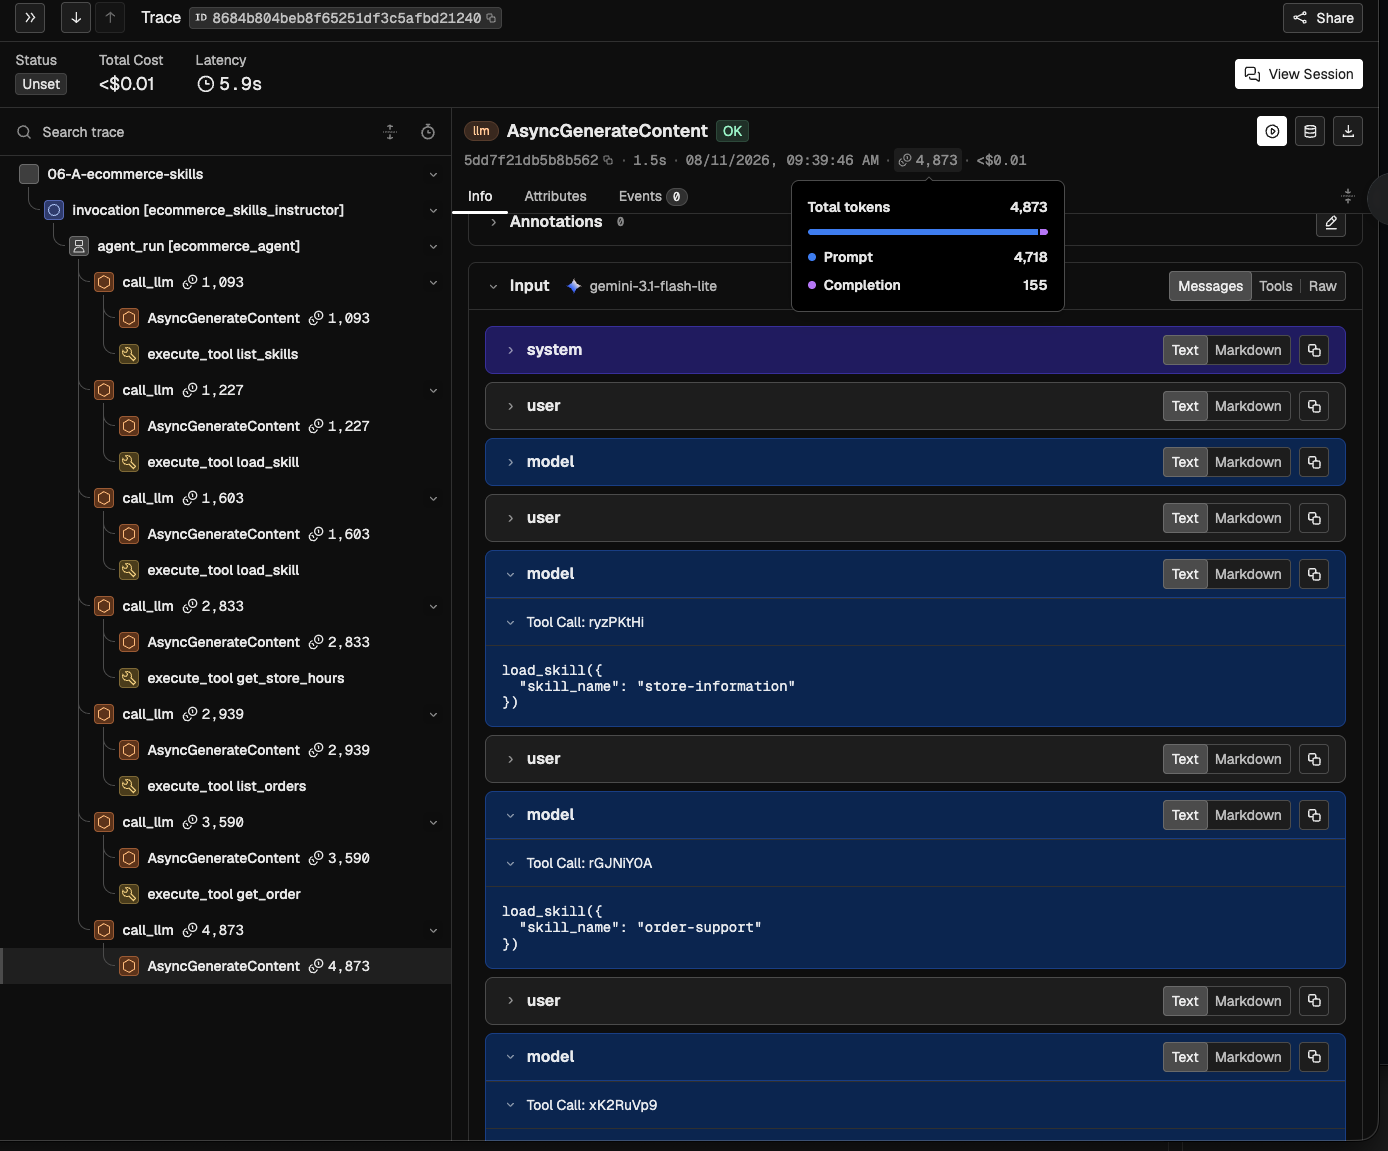

### 🧑‍🤝‍🧑 Part B — one parent with two specialist subagents

The parent owns the user conversation. It delegates bounded work to
an Order specialist and a Store specialist. Each specialist has its
own prompt, tools, context, and model loop, then returns a result.

In [ ]:
order_skill_toolset = load_order_skill_tools()
store_information_specialist = Agent(
    name="store_information_specialist",
    model=GOOGLE_MODEL,
    mode="single_turn",
    instruction=(
        "Answer the delegated store-hours question with get_store_hours. "
        "Return only grounded store, day, hours, and time-zone facts."
    ),
    tools=[get_store_hours],
)
order_specialist = Agent(
    name="order_specialist",
    model=GOOGLE_MODEL,
    mode="single_turn",
    instruction=(
        "Complete the delegated order question with the order-support "
        "Skill and return one concise grounded result to the parent."
    ),
    tools=[order_skill_toolset],
)
ecommerce_subagent_agent = Agent(
    name="ecommerce_agent",
    model=GOOGLE_MODEL,
    instruction=(
        "Delegate store-hours work to store_information_specialist and "
        "order work to order_specialist, then combine their returned facts."
    ),
    sub_agents=[store_information_specialist, order_specialist],
)
ecommerce_subagent_runner = make_workshop_runner(
    ecommerce_subagent_agent,
    "ecommerce_subagents_instructor",
)

#### ▶️ Run the subagent architecture

In Phoenix, find the parent delegation calls, both specialist loops,
and the final parent synthesis.

In [ ]:
_ = await run_traced_turn(
    trace_name="06-B-ecommerce-subagents",
    runner=ecommerce_subagent_runner,
    prompt=MIXED_PROMPT,
    session_id="06-B-ecommerce-subagents",
)

#### Flush and inspect the ecommerce subagents trace

Flush batching before opening Phoenix. In the trace, identify the
model decision, every tool boundary, and the evidence returned to the
final response.

In [ ]:
tracer_provider.force_flush()
print("Flushed ecommerce subagents trace to Phoenix project", PROJECT_NAME)

#### 🔎 Trace review — Ecommerce subagents

**What to notice**

- The parent delegates two bounded jobs, and Phoenix shows separate `agent_run` spans for the Store and Order specialists before the parent combines their results.
- Separate agent boundaries improve isolation and ownership, with the tradeoff of additional model boundaries, latency, and handoff.
The trace makes separate agent boundaries visible before the parent combines the results.

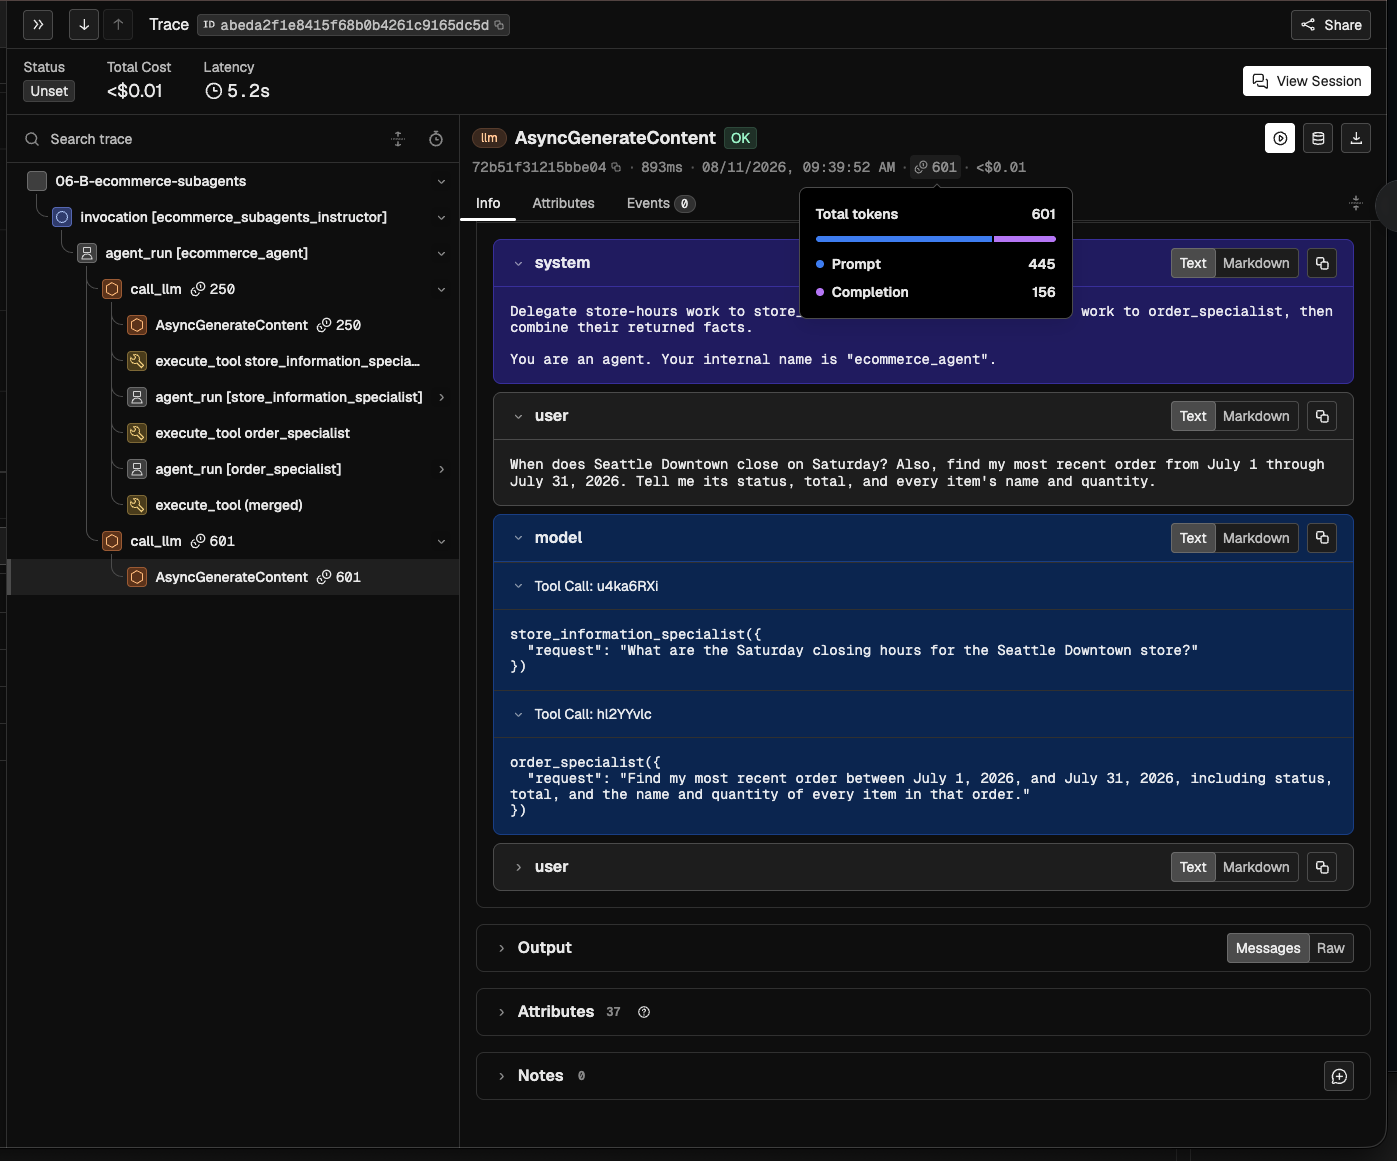

## Checks

Compare the two Phoenix traces:

1. **How many model calls occurred in each architecture?**
2. **Which architecture used more input and output tokens?**
3. **Where did both domains share context?**
4. **Where did delegation create separate specialist contexts?**
5. **Which boundary is easier to explain for this small example?**

### 🧹 Clean up

Close the shared MCP connections after both traces are flushed.

In [ ]:
await close_workshop_tools()
print("🧹 Ecommerce instructor connections closed.")

## Next Steps

Notebook 07 asks learners to build Product search with direct MCP
tools and then with a Skill. Notebook 08 asks them to implement and
compare both ecommerce composition patterns after the session.